In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loading the dataset from UCIML Repo

In [2]:
!pip install ucimlrepo


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from ucimlrepo import fetch_ucirepo
concrete = fetch_ucirepo(id=165)

In [4]:
X = concrete.data.features
y = concrete.data.targets

In [5]:
df = pd.DataFrame(X)
df['Concrete compressive strength'] = y
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast Furnace Slag             1030 non-null   float64
 2   Fly Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse Aggregate               1030 non-null   float64
 6   Fine Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete compressive strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


Handling missing values (if any)

In [7]:
# Missing values
df.isnull().sum()

Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete compressive strength    0
dtype: int64

No missing values are present in the given dataset

Handling duplicate values (if any)

In [8]:
# Duplicate value check and removal
df.duplicated().sum()

np.int64(25)

In [9]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(1005, 9)

Splitting the dataset into training, test and validation datasets

In [11]:
X = df.drop('Concrete compressive strength', axis=1)
y = df['Concrete compressive strength']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_dummy, y_train, y_dummy = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_dummy, y_dummy, test_size=0.5, random_state=42)

In [14]:
print("Size of training dataset:", X_train.shape)
print("Size of testing dataset:", X_test.shape)
print("Size of validation dataset:", X_val.shape)

Size of training dataset: (703, 8)
Size of testing dataset: (151, 8)
Size of validation dataset: (151, 8)


# Implementing Adaboost Regressor from scratch

In [15]:
epsilon = 1e-8

In [16]:
# Helper functions for Adaboost Regressor
def compute_error(y, y_pred, w_i): # computes the weighted error of normalized absolute error
  # normalize the absolute error to [0,1]
  abs_error = np.abs(y - y_pred)
  max_error = np.max(abs_error)
  normalized_error = abs_error / (max_error + epsilon)

  return (sum(w_i * normalized_error)) / sum(w_i)

def beta(error): # computes the value of beta
  return ((error)/(1-error+epsilon))

def update_weights(w_i, beta, y, y_pred): # computes the value of normalized weights
  abs_error = np.abs(y - y_pred)
  max_error = np.max(abs_error)
  normalized_error = abs_error / max_error

  return w_i*(np.power(beta, (1-normalized_error))) / np.sum(w_i*(np.power(beta, (1-normalized_error))))

Define AdaBoost_Regressor Class

In [17]:
from sklearn.tree import DecisionTreeRegressor

In [18]:
class AdaBoost_Regressor_Scratch:
  def __init__(self):
    self.alphas = [] # list to store alphas
    self.G_M = [] # List to store weak regressors
    self.M = None # Number of boosting rounds

  def fit(self, X, y, M):
    self.alphas = [] # Initialize the list for storing alpha values
    self.M = M # Store the number of boosting rounds

    m = len(X) # Get the number of samples in the dataset
    w_i = np.ones(m) / m  # Initialize sample weights uniformly

    for _ in range(M): # Iterate M times (boosting rounds)
      G_m = DecisionTreeRegressor(max_depth=1)
      G_m.fit(X, y, sample_weight=w_i) # Train the weak learner with sample weights
      y_pred = G_m.predict(X) # Make predictions on the training data
      error_m = compute_error(y, y_pred, w_i) # Compute the weighted error
      if error_m >= 0.5:
        G_m = DecisionTreeRegressor(max_depth=2)
        G_m.fit(X,y,sample_weight=w_i)
        y_pred = G_m.predict(X)
        error_m = compute_error(y, y_pred, w_i)

        if error_m >= 0.5: # ignore for predictions if weak learner still does not improve
          beta_m = 1
          alpha_m = 0
          self.G_M.append(G_m)
          self.alphas.append(alpha_m)
          continue # skip rest of loop, move to next round

      beta_m = beta(error_m)
      alpha_m = np.log(1/beta_m)
      w_i = update_weights(w_i, beta(error_m), y, y_pred) # Update the sample weights

      self.G_M.append(G_m) # Add the trained weak learner to the list
      self.alphas.append(alpha_m) # Add the alpha value to the list

  def prediction(self, X):
    weak_preds = np.array([self.alphas[m] * self.G_M[m].predict(X) for m in range(self.M)])
    return (np.sum(weak_preds, axis=0))/(np.sum(self.alphas))

# Choosing a suitable value of M

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
M_values = [5, 10, 20, 40, 60, 80, 100, 150, 200, 500, 1000, 5000, 10000]
r2_scores = []

In [21]:
for M in M_values:
  ada_reg = AdaBoost_Regressor_Scratch()
  ada_reg.fit(X_train, y_train, M)
  y_pred = ada_reg.prediction(X_val)
  r2 = r2_score(y_val, y_pred)
  r2_scores.append(r2)
  print(f"M = {M}, R2 Score = {r2}")

M = 5, R2 Score = 0.3766410178607036
M = 10, R2 Score = 0.41106324981381626
M = 20, R2 Score = 0.42812706528085664
M = 40, R2 Score = 0.4427630622488
M = 60, R2 Score = 0.44751322995472276
M = 80, R2 Score = 0.4562577813413027
M = 100, R2 Score = 0.4565184051198773
M = 150, R2 Score = 0.46037217217239146
M = 200, R2 Score = 0.4917958946349408
M = 500, R2 Score = 0.5301565754205676
M = 1000, R2 Score = 0.5575425215708746
M = 5000, R2 Score = 0.5705471156866804
M = 10000, R2 Score = 0.5713971336342609


# Plot of R2 vs M for different values of M

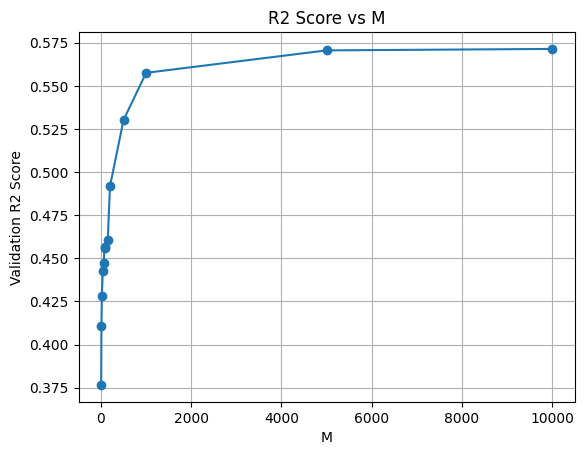

In [22]:
# R2 vs M plot
plt.plot(figsize=(8,5))
plt.plot(M_values, r2_scores, marker='o')
plt.xlabel('M')
plt.ylabel('Validation R2 Score')
plt.title('R2 Score vs M')
plt.grid(True)
plt.show()

In [23]:
best_M = M_values[np.argmax(r2_scores)]
print(f"Best M value: {best_M}")

Best M value: 10000


Check R2 score and MSE value on test set

In [24]:
ada_reg_test = AdaBoost_Regressor_Scratch()
ada_reg_test.fit(X_train, y_train, best_M)
y_pred_test = ada_reg_test.prediction(X_test)

In [25]:
print(f"R2 score on test set: {r2_score(y_test, y_pred_test)}")
print(f"MSE on test set: {mean_squared_error(y_test, y_pred_test)}")

R2 score on test set: 0.5903247580739202
MSE on test set: 132.6140211758382


Scatter plot of predictions vs ground truth

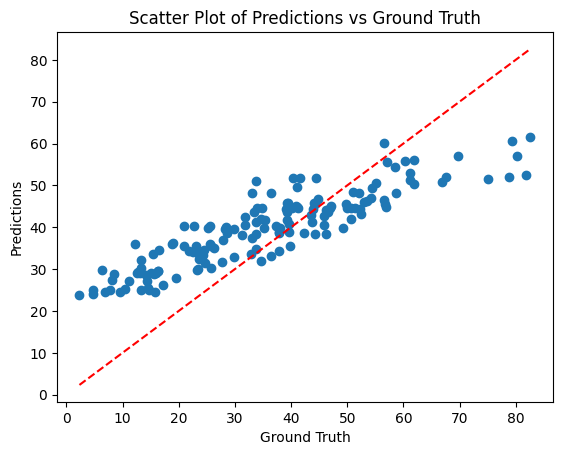

In [26]:
# Scatter plot of predictions vs ground truth
plt.scatter(y_test, y_pred_test)
plt.xlabel('Ground Truth')
plt.ylabel('Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
plt.title('Scatter Plot of Predictions vs Ground Truth')
plt.show()

# Scikit learn implementation of Adaboost Regressor

In [27]:
from sklearn.ensemble import AdaBoostRegressor

In [28]:
adaboost_reg_sklearn = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=1),n_estimators=best_M,random_state=42)
adaboost_reg_sklearn.fit(X_train, y_train)
y_pred_sklearn = adaboost_reg_sklearn.predict(X_test)

In [29]:
print(f"R2 score on test set: {r2_score(y_test, y_pred_sklearn)}")
print(f"MSE on test set: {mean_squared_error(y_test, y_pred_sklearn)}")

R2 score on test set: 0.5396547967161419
MSE on test set: 149.01615301296724


Scatter plot of predictions vs ground truth

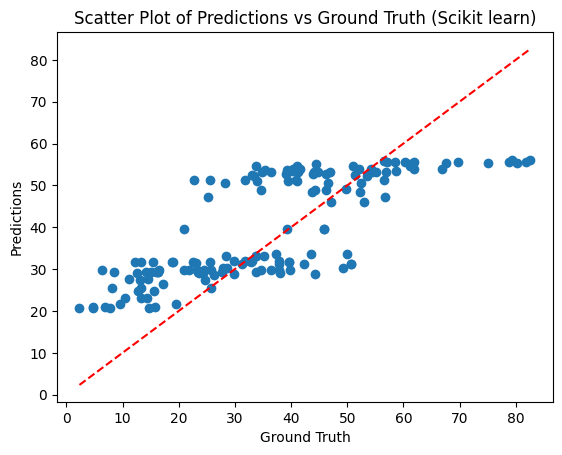

In [30]:
# Scatter plot of predictions vs ground truth
plt.scatter(y_test, y_pred_sklearn)
plt.xlabel('Ground Truth')
plt.ylabel('Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
plt.title('Scatter Plot of Predictions vs Ground Truth (Scikit learn)')
plt.show()

# Comparison between scratch implementation and scikit learn implementation

In [31]:
# Comparison between scratch implementation and scikit learn implementation of Adaboost regressor
print("Scratch Implementation:")
print(f"R2 score on test set: {r2_score(y_test, y_pred_test)}")
print(f"MSE on test set: {mean_squared_error(y_test, y_pred_test)}")
print("Scikit learn Implementation:")
print(f"R2 score on test set: {r2_score(y_test, y_pred_sklearn)}")
print(f"MSE on test set: {mean_squared_error(y_test, y_pred_sklearn)}")

Scratch Implementation:
R2 score on test set: 0.5903247580739202
MSE on test set: 132.6140211758382
Scikit learn Implementation:
R2 score on test set: 0.5396547967161419
MSE on test set: 149.01615301296724
